# Assignment 2
2025 | IN6227 Data Mining | Roshani Ayu Pranasti | G2504973A

## Install Orange Association Library

- Documentation: https://orange3-associate.readthedocs.io/en/latest/
- GitHub: https://github.com/biolab/orange3-associate/tree/master

In [1]:
!pip3 install orange3 orange3-associate

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## Import Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import warnings
from itertools import chain, combinations # For brute-force association rules mining
from orangecontrib.associate.fpgrowth import *  # Association rules mining in Orange 3

warnings.filterwarnings('ignore')

## Dataset Definition
I have prepared 1 dataset that is Bakery Sales Dataset. More about the dataset can be read on `README.md`.
1. **Bakery Sales Dataset**: `bakery_sales.csv`

With this dataset, I will further prepare several datasets varying sizes on the number of unique items, but the number of transactions does not change.

## Exploratory Data Analysis

In [3]:
# Load dataset
bakery_dataset = pd.read_csv("bakery_sales.csv")
display(bakery_dataset)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend
...,...,...,...,...,...
20502,9682,Coffee,4/9/2017 14:32,afternoon,weekend
20503,9682,Tea,4/9/2017 14:32,afternoon,weekend
20504,9683,Coffee,4/9/2017 14:57,afternoon,weekend
20505,9683,Pastry,4/9/2017 14:57,afternoon,weekend


In [4]:
print("Number of attributes in dataset:", bakery_dataset.shape[1])
print("Number of data in dataset:", bakery_dataset.shape[0], "\n")
bakery_dataset.info()

Number of attributes in dataset: 5
Number of data in dataset: 20507 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [5]:
print("Number of unknown or missing values in dataset:")
bakery_dataset.isnull().sum()

Number of unknown or missing values in dataset:


Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64

In [6]:
# Check unique values for each column
for column in bakery_dataset.columns:
    print(column, "\n", bakery_dataset[column].unique())

Transaction 
 [   1    2    3 ... 9682 9683 9684]
Item 
 ['Bread' 'Scandinavian' 'Hot chocolate' 'Jam' 'Cookies' 'Muffin' 'Coffee'
 'Pastry' 'Medialuna' 'Tea' 'Tartine' 'Basket' 'Mineral water'
 'Farm House' 'Fudge' 'Juice' "Ella's Kitchen Pouches" 'Victorian Sponge'
 'Frittata' 'Hearty & Seasonal' 'Soup' 'Pick and Mix Bowls' 'Smoothies'
 'Cake' 'Mighty Protein' 'Chicken sand' 'Coke' 'My-5 Fruit Shoot'
 'Focaccia' 'Sandwich' 'Alfajores' 'Eggs' 'Brownie' 'Dulce de Leche'
 'Honey' 'The BART' 'Granola' 'Fairy Doors' 'Empanadas' 'Keeping It Local'
 'Art Tray' 'Bowl Nic Pitt' 'Bread Pudding' 'Adjustment' 'Truffles'
 'Chimichurri Oil' 'Bacon' 'Spread' 'Kids biscuit' 'Siblings'
 'Caramel bites' 'Jammie Dodgers' 'Tiffin' 'Olum & polenta' 'Polenta'
 'The Nomad' 'Hack the stack' 'Bakewell' 'Lemon and coconut' 'Toast'
 'Scone' 'Crepes' 'Vegan mincepie' 'Bare Popcorn' 'Muesli' 'Crisps'
 'Pintxos' 'Gingerbread syrup' 'Panatone' 'Brioche and salami'
 'Afternoon with the baker' 'Salad' 'Chicken Stew'

In [7]:
# Check unique values in Transaction column
uniqe_transactions = bakery_dataset["Transaction"].unique()
last_transaction = uniqe_transactions[-1]
print("Unique transactions count:", len(uniqe_transactions))
print("Last transaction:", last_transaction)

# Check missing transactions
missing_transactions = [i for i in range(1, last_transaction + 1) if i not in uniqe_transactions]
print("Missing transactions count:", len(missing_transactions))
print("Missing transactions:\n", missing_transactions)

Unique transactions count: 9465
Last transaction: 9684
Missing transactions count: 219
Missing transactions:
 [53, 177, 273, 315, 362, 434, 472, 496, 561, 582, 607, 614, 619, 649, 679, 694, 731, 801, 823, 827, 1045, 1067, 1079, 1113, 1302, 1312, 1385, 1481, 1489, 1596, 1628, 1766, 1883, 1884, 1918, 2032, 2046, 2047, 2056, 2060, 2064, 2139, 2233, 2240, 2247, 2292, 2293, 2299, 2306, 2336, 2345, 2349, 2394, 2405, 2411, 2455, 2456, 2465, 2480, 2483, 2484, 2485, 2531, 2542, 2544, 2658, 2779, 2784, 2864, 2883, 2947, 2965, 2999, 3012, 3014, 3016, 3057, 3072, 3132, 3140, 3254, 3269, 3273, 3302, 3308, 3345, 3365, 3511, 3528, 3544, 3553, 3569, 3604, 3607, 3671, 3745, 3862, 3863, 3963, 3973, 4021, 4084, 4091, 4092, 4093, 4122, 4137, 4207, 4255, 4282, 4301, 4318, 4466, 4467, 4469, 4470, 4473, 4474, 4481, 4488, 4523, 4526, 4538, 4544, 4580, 4621, 4633, 4648, 4700, 4755, 4809, 4810, 4815, 4829, 4947, 4970, 5053, 5074, 5085, 5091, 5186, 5246, 5266, 5270, 5330, 5331, 5332, 5333, 5334, 5335, 5351, 5439

## Data Preprocessing

### Encode Transactions using One-Hot Encoding
For a simple association rules mining task, the goal is to find relationships between items within a transaction, regardless of when it happened. In this case, the time of day (`period_day`) or day of the week (`weekday_weekend`) is considered metadata about the transaction. This is why these columns were ignored when I converted the data to the required one-hot encoded format.

In [8]:
# Use get_dummies to one-hot encode the 'Item' column
one_hot_dataset = pd.get_dummies(bakery_dataset["Item"])

# Combine it with the 'Transaction' column
one_hot_dataset = pd.concat([bakery_dataset["Transaction"], one_hot_dataset], axis=1)
display(one_hot_dataset)

# Group by transaction and sum the one-hot encoded columns
# This counts the occurrences of each item in each transaction
encoded_dataset = one_hot_dataset.groupby('Transaction').sum()

# Convert counts to binary (0 or 1)
encoded_dataset = encoded_dataset.map(lambda x: 1 if x > 0 else 0)
display(encoded_dataset)

,Transaction,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20502,9682,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20503,9682,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20504,9683,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20505,9683,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9681,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
9682,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Vary Dataset in Different Sizes based on Number of Unique Items
I will vary sizes on the number of unique items, but keeping the number of transactions does not change

In [9]:
# Define constants to vary dataset
num_transactions = 26 # Number of transactions in each dataset
num_datasets = 7 # Number of datasets
random_state = np.random.RandomState(seed=1271999) # To generate same sample everytime

result_datasets = []
temp_columns = set() # Flag to get different number of columns or unique items

In [10]:
# Generate new datasets
while len(temp_columns) < num_datasets:
    # Randomly sample 'num_transactions' rows from the original dataset
    sample_dataset = encoded_dataset.sample(n=num_transactions, random_state=random_state)

    # Identify and remove items (columns) that have no occurrences in this specific sample
    all_items = list(sample_dataset.sum().sort_values(ascending=False).items())
    item_names = [item_name for (item_name, count) in all_items if count > 0]

    # Create a new, cleaned dataset with only the columns that contain data
    new_dataset = sample_dataset[item_names]
    num_columns = len(new_dataset.columns)
    
    # Check if already created a dataset with this number of unique items
    if num_columns not in temp_columns:
        temp_columns.add(num_columns)
        result_datasets.append(new_dataset)

In [11]:
# Display new datasets
for (index, dataset) in enumerate(result_datasets):
    print("----- Dataset", index+1, "-----")
    print("Number of unique items:", dataset.shape[1])
    print("Number of transactions:", dataset.shape[0])
    display(dataset)

----- Dataset 1 -----
Number of unique items: 23
Number of transactions: 26


,Coffee,Bread,Hot chocolate,Tea,Cake,Alfajores,Medialuna,Tartine,Scone,Pastry,...,Raspberry shortbread sandwich,Sandwich,Frittata,Fudge,Muffin,Jam,Jammie Dodgers,Cookies,Brownie,Baguette
Transaction,,,,,,,,,,,,,,,,,,,,,
3690,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9051,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
975,0,1,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
7532,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2880,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7403,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2519,1,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
6053,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4759,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


----- Dataset 2 -----
Number of unique items: 21
Number of transactions: 26


,Coffee,Tea,Bread,Cake,Pastry,Juice,Medialuna,Chicken Stew,Farm House,Cookies,...,Tiffin,Toast,Fudge,Hearty & Seasonal,Hot chocolate,Alfajores,Truffles,Scandinavian,Spanish Brunch,Smoothies
Transaction,,,,,,,,,,,,,,,,,,,,,
5272,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
882,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3094,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6848,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8300,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
702,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7043,1,0,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
7784,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1527,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


----- Dataset 3 -----
Number of unique items: 24
Number of transactions: 26


...

,Coffee,Bread,Medialuna,Hot chocolate,Toast,Muffin,Soup,Brownie,Cake,Tea,...,Sandwich,Chicken Stew,Coke,Mineral water,Jammie Dodgers,Spanish Brunch,Cookies,Baguette,Alfajores,Truffles
Transaction,,,,,,,,,,,,,,,,,,,,,
6604,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3507,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1799,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5122,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6525,1,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1790,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1546,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8366,0,0,0,0,0,0,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0
7846,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1


----- Dataset 6 -----
Number of unique items: 20
Number of transactions: 26


,Coffee,Bread,Cake,Sandwich,Scandinavian,Brownie,Cookies,Hot chocolate,Alfajores,Tea,Farm House,Truffles,Jammie Dodgers,Hearty & Seasonal,Jam,Eggs,Pastry,Muffin,Toast,Juice
Transaction,,,,,,,,,,,,,,,,,,,,
6884,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8059,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4195,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
8520,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7038,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8768,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1255,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1024,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6728,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


----- Dataset 7 -----
Number of unique items: 18
Number of transactions: 26


,Bread,Coffee,Sandwich,Cake,Tea,Salad,Pastry,Scone,Soup,Jam,Alfajores,Hot chocolate,Keeping It Local,Medialuna,Spanish Brunch,Mineral water,Cookies,Muffin
Transaction,,,,,,,,,,,,,,,,,,
7578,0,0,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0
5955,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3473,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5152,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
6079,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8987,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2681,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2263,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
8375,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Orange 3 Association Rules Mining

Based on its GitHub codebase, Orange 3 uses the FP-Growth (Frequent Pattern Growth) algorithm for its association rules mining.
- Orange 3 associate FP-growth: https://github.com/biolab/orange3-associate/blob/master/orangecontrib/associate/fpgrowth.py

In [12]:
min_support = 0.05
min_confidence = 0.5

In [13]:
orange_frequent_itemsets_times = []
orange_association_rules_times = []
orange_total_times = []
orange_results_dfs = []

for (index, dataset) in enumerate(result_datasets):
    # Create a mapping from column index to item name
    mapping = {i: item_name for i, item_name in enumerate(dataset.columns)}

    # Step 1: Generate frequent itemsets
    start_orange_association_rules = time.time()
    itemsets = dict(frequent_itemsets(dataset.values, min_support=min_support))
    end_orange_frequent_itemsets = time.time()

    # Step 2: Generate high-confidence rules from the frequent itemsets
    rules = list(association_rules(itemsets, min_confidence=min_confidence))
    end_orange_association_rules = time.time()

    # Present processed rules as results
    orange_results = []
    for antecedent, consequent, support, confidence in rules:
        antecedent_list = [mapping[item] for item in antecedent]
        consequent_list = [mapping[item] for item in consequent]

        orange_results.append({
            "Antecedent": ", ".join(antecedent_list),
            "Consequent": ", ".join(consequent_list),
            "Support": support,
            "Confidence": confidence
        })
    
    # Display results of orange 3 association rules mining 
    print("----- Dataset", index+1, "- Orange 3 Association Rules Mining -----")
    print("Number of unique items:", dataset.shape[1])
    print("Number of transactions:", dataset.shape[0])

    orange_frequent_itemsets_time = end_orange_frequent_itemsets - start_orange_association_rules
    orange_association_rules_time = end_orange_association_rules - end_orange_frequent_itemsets
    orange_total_time = end_orange_association_rules - start_orange_association_rules
    orange_frequent_itemsets_times.append(orange_frequent_itemsets_time)
    orange_association_rules_times.append(orange_association_rules_time)
    orange_total_times.append(orange_total_time)
    print("Frequent itemsets generation time:", orange_frequent_itemsets_time)
    print("High-confidence rules generation time:", orange_association_rules_time)
    print("Total time:", orange_total_time)

    orange_results_df = pd.DataFrame(orange_results)
    orange_results_dfs.append(orange_results_df)
    print("Rules:")
    display(orange_results_df)

----- Dataset 1 - Orange 3 Association Rules Mining -----
Number of unique items: 23
Number of transactions: 26
Frequent itemsets generation time: 0.0001468658447265625
High-confidence rules generation time: 1.4066696166992188e-05
Total time: 0.0001609325408935547
Rules:


,Antecedent,Consequent,Support,Confidence
0,"Hot chocolate, Cake",Coffee,2,0.666667
1,"Coffee, Cake",Hot chocolate,2,1.000000
2,Cake,"Coffee, Hot chocolate",2,0.500000
3,"Coffee, Hot chocolate",Cake,2,0.666667
4,Hot chocolate,Coffee,3,0.600000
5,Tea,Bread,2,0.500000
6,Cake,Coffee,2,0.500000
7,Cake,Hot chocolate,3,0.750000
8,Hot chocolate,Cake,3,0.600000
9,Cake,Tea,2,0.500000


----- Dataset 2 - Orange 3 Association Rules Mining -----
Number of unique items: 21
Number of transactions: 26
Frequent itemsets generation time: 0.0001270771026611328
High-confidence rules generation time: 1.4066696166992188e-05
Total time: 0.000141143798828125
Rules:


,Antecedent,Consequent,Support,Confidence
0,Bread,Coffee,5,0.833333
1,Cake,Coffee,2,0.500000
2,Pastry,Coffee,2,0.666667
3,Cookies,Coffee,2,1.000000
4,Bakewell,Tea,2,1.000000


----- Dataset 3 - Orange 3 Association Rules Mining -----
Number of unique items: 24
Number of transactions: 26
Frequent itemsets generation time: 7.390975952148438e-05
High-confidence rules generation time: 1.0013580322265625e-05
Total time: 8.392333984375e-05
Rules:


...

,Antecedent,Consequent,Support,Confidence
0,"Medialuna, Toast",Bread,2,1.000000
1,"Bread, Toast",Medialuna,2,1.000000
2,Toast,"Bread, Medialuna",2,0.666667
3,"Bread, Medialuna",Toast,2,1.000000
4,Medialuna,Coffee,4,0.571429
5,Hot chocolate,Bread,2,0.666667
6,Toast,Bread,2,0.666667
7,Toast,Medialuna,2,0.666667
8,Toast,Hot chocolate,2,0.666667
9,Hot chocolate,Toast,2,0.666667


----- Dataset 6 - Orange 3 Association Rules Mining -----
Number of unique items: 20
Number of transactions: 26
Frequent itemsets generation time: 0.00011992454528808594
High-confidence rules generation time: 0.00015091896057128906
Total time: 0.000270843505859375
Rules:


,Antecedent,Consequent,Support,Confidence
0,"Alfajores, Sandwich, Cookies, Hot chocolate",Coffee,2,1.000000
1,"Coffee, Alfajores, Cookies, Hot chocolate",Sandwich,2,1.000000
2,"Alfajores, Cookies, Hot chocolate","Coffee, Sandwich",2,1.000000
3,"Coffee, Alfajores, Sandwich, Hot chocolate",Cookies,2,1.000000
4,"Alfajores, Sandwich, Hot chocolate","Coffee, Cookies",2,1.000000
...,...,...,...,...
164,Alfajores,Sandwich,2,0.666667
165,Cookies,Alfajores,2,0.666667
166,Alfajores,Cookies,2,0.666667
167,Hot chocolate,Alfajores,2,0.666667


----- Dataset 7 - Orange 3 Association Rules Mining -----
Number of unique items: 18
Number of transactions: 26
Frequent itemsets generation time: 9.179115295410156e-05
High-confidence rules generation time: 3.0040740966796875e-05
Total time: 0.00012183189392089844
Rules:


,Antecedent,Consequent,Support,Confidence
0,"Coffee, Sandwich",Bread,2,0.500000
1,"Bread, Sandwich",Coffee,2,0.666667
2,"Bread, Coffee",Sandwich,2,0.500000
3,"Sandwich, Cake",Coffee,2,1.000000
4,"Coffee, Cake",Sandwich,2,1.000000
5,"Coffee, Sandwich",Cake,2,0.500000
6,Sandwich,Bread,3,0.500000
7,Sandwich,Coffee,4,0.666667
8,Cake,Bread,3,0.600000
9,Tea,Coffee,2,0.500000


## Brute-Force Association Rules Mining

In [14]:
# Define brute-force algorithm function
def get_subsets(items):
    """
    Generates all non-empty subsets from a list of items.
    Example: get_subsets(['a', 'b']) -> {'a'}, {'b'}, {'a', 'b'}
    """
    return chain.from_iterable(combinations(items, r) for r in range(1, len(items) + 1))

def brute_force_frequent_itemsets(transactions, min_support):
    """
    Generates frequent itemsets using a brute force approach.

    Args:
        transactions (list of sets): The transaction database.
        min_support (float): The minimum support threshold.

    Returns:
        dict: A dictionary of frequent itemsets (frozenset) and 
              their support values (float).
    """
    unique_items = sorted(list(set(item for transaction in transactions for item in transaction)))
    all_itemsets = [frozenset(subset) for subset in get_subsets(unique_items)]
    num_transactions = len(transactions)

    itemset_supports = {}
    for itemset in all_itemsets:
        count = 0
        for transaction in transactions:
            if itemset.issubset(transaction):
                count += 1
        support = count / num_transactions
        if support >= min_support:
            itemset_supports[itemset] = support

    return itemset_supports

def brute_force_association_rules(itemset_supports, min_confidence):
    """
    Generates association rules using a brute force approach.

    Args:
        transactions (list of sets): The transaction database.
        min_confidence (float): The minimum confidence threshold.

    Returns:
        list: A list of tuples, where each tuple represents a rule
              (antecedent, consequent, support, confidence).
    """
    final_rules = []

    for itemset, support in itemset_supports.items():
        if len(itemset) > 1:
            # Generate all possible rules from this itemset
            for antecedent in (frozenset(subset) for subset in get_subsets(itemset) if len(subset) < len(itemset)):
                consequent = itemset - antecedent
                
                # Check if the antecedent exists in our support dictionary
                if antecedent in itemset_supports:
                    antecedent_support = itemset_supports[antecedent]
                    confidence = support / antecedent_support
                    
                    if confidence >= min_confidence:
                        final_rules.append((antecedent, consequent, support, confidence))

    return final_rules

In [15]:
brute_force_frequent_itemsets_times = []
brute_force_association_rules_times = []
brute_force_total_times = []
brute_force_results_dfs = []

# Convert data into a list of sets
def convert_into_list_of_sets(data):
    transactions = []
    for index, row in data.iterrows():
        # For each row, get the column names where the value is 1
        itemset = set(row.index[row == 1])
        transactions.append(itemset)

    return transactions

for (index, dataset) in enumerate(result_datasets):
    transactions = convert_into_list_of_sets(dataset)

    # Step 1: Generate frequent itemsets
    start_brute_force_association_rules = time.time()
    itemset_supports = brute_force_frequent_itemsets(transactions, min_support=min_support)
    end_brute_force_frequent_itemsets = time.time()

    # Step 2: Generate high-confidence rules from the frequent itemsets
    rules = brute_force_association_rules(itemset_supports, min_confidence=min_confidence)
    end_brute_force_association_rules = time.time()

    # Present processed rules as results
    brute_force_results = []
    for antecedent, consequent, support, confidence in rules:
        brute_force_results.append({
            "Antecedent": ", ".join(antecedent),
            "Consequent": ", ".join(consequent),
            "Support": support,
            "Confidence": confidence
        })
    
    # Display results of brute-force association rules mining 
    print("----- Dataset", index+1, "- Brute-Force Association Rules Mining -----")
    print("Number of unique items:", dataset.shape[1])
    print("Number of transactions:", dataset.shape[0])

    brute_force_frequent_itemsets_time = end_brute_force_frequent_itemsets - start_brute_force_association_rules
    brute_force_association_rules_time = end_brute_force_association_rules - end_brute_force_frequent_itemsets
    brute_force_total_time = end_brute_force_association_rules - start_brute_force_association_rules
    brute_force_frequent_itemsets_times.append(brute_force_frequent_itemsets_time)
    brute_force_association_rules_times.append(brute_force_association_rules_time)
    brute_force_total_times.append(brute_force_total_time)
    print("Frequent itemsets generation time:", brute_force_frequent_itemsets_time)
    print("High-confidence rules generation time:", brute_force_association_rules_time)
    print("Total time:", brute_force_total_time)

    brute_force_results_df = pd.DataFrame(brute_force_results)
    brute_force_results_dfs.append(brute_force_results_df)
    print("Rules:")
    display(brute_force_results_df)

----- Dataset 1 - Brute-Force Association Rules Mining -----
Number of unique items: 23
Number of transactions: 26
Frequent itemsets generation time: 16.96324920654297
High-confidence rules generation time: 4.482269287109375e-05
Total time: 16.96329402923584
Rules:


,Antecedent,Consequent,Support,Confidence
0,Tea,Bread,0.076923,0.500000
1,Cake,Coffee,0.076923,0.500000
2,Hot chocolate,Cake,0.115385,0.600000
3,Cake,Hot chocolate,0.115385,0.750000
4,Tea,Cake,0.076923,0.500000
5,Cake,Tea,0.076923,0.500000
6,Hot chocolate,Coffee,0.115385,0.600000
7,Cake,"Coffee, Hot chocolate",0.076923,0.500000
8,"Coffee, Hot chocolate",Cake,0.076923,0.666667
9,"Coffee, Cake",Hot chocolate,0.076923,1.000000


----- Dataset 2 - Brute-Force Association Rules Mining -----
Number of unique items: 21
Number of transactions: 26
Frequent itemsets generation time: 3.051908016204834
High-confidence rules generation time: 3.0040740966796875e-05
Total time: 3.051938056945801
Rules:


,Antecedent,Consequent,Support,Confidence
0,Bakewell,Tea,0.076923,1.000000
1,Bread,Coffee,0.192308,0.833333
2,Cake,Coffee,0.076923,0.500000
3,Cookies,Coffee,0.076923,1.000000
4,Pastry,Coffee,0.076923,0.666667


----- Dataset 3 - Brute-Force Association Rules Mining -----
Number of unique items: 24
Number of transactions: 26
Frequent itemsets generation time: 64.97422480583191
High-confidence rules generation time: 0.0001430511474609375
Total time: 64.97436785697937
Rules:


...

,Antecedent,Consequent,Support,Confidence
0,Hot chocolate,Bread,0.076923,0.666667
1,Toast,Bread,0.076923,0.666667
2,Medialuna,Coffee,0.153846,0.571429
3,Hot chocolate,Toast,0.076923,0.666667
4,Toast,Hot chocolate,0.076923,0.666667
5,Toast,Medialuna,0.076923,0.666667
6,Toast,"Medialuna, Bread",0.076923,0.666667
7,"Medialuna, Toast",Bread,0.076923,1.000000
8,"Medialuna, Bread",Toast,0.076923,1.000000
9,"Bread, Toast",Medialuna,0.076923,1.000000


----- Dataset 6 - Brute-Force Association Rules Mining -----
Number of unique items: 20
Number of transactions: 26
Frequent itemsets generation time: 1.9933040142059326
High-confidence rules generation time: 0.00010919570922851562
Total time: 1.9934132099151611
Rules:


,Antecedent,Consequent,Support,Confidence
0,Alfajores,Coffee,0.115385,1.000000
1,Alfajores,Cookies,0.076923,0.666667
2,Cookies,Alfajores,0.076923,0.666667
3,Alfajores,Hot chocolate,0.076923,0.666667
4,Hot chocolate,Alfajores,0.076923,0.666667
...,...,...,...,...
164,"Alfajores, Coffee, Cookies, Hot chocolate",Sandwich,0.076923,1.000000
165,"Alfajores, Coffee, Cookies, Sandwich",Hot chocolate,0.076923,1.000000
166,"Alfajores, Coffee, Hot chocolate, Sandwich",Cookies,0.076923,1.000000
167,"Alfajores, Cookies, Sandwich, Hot chocolate",Coffee,0.076923,1.000000


----- Dataset 7 - Brute-Force Association Rules Mining -----
Number of unique items: 18
Number of transactions: 26
Frequent itemsets generation time: 0.3137521743774414
High-confidence rules generation time: 5.364418029785156e-05
Total time: 0.31380581855773926
Rules:


,Antecedent,Consequent,Support,Confidence
0,Alfajores,Bread,0.076923,1.000000
1,Cake,Bread,0.115385,0.600000
2,Sandwich,Bread,0.115385,0.500000
3,Tea,Cake,0.076923,0.500000
4,Jam,Coffee,0.076923,1.000000
5,Salad,Coffee,0.076923,0.666667
6,Sandwich,Coffee,0.153846,0.666667
7,Soup,Coffee,0.076923,1.000000
8,Tea,Coffee,0.076923,0.500000
9,"Sandwich, Coffee",Bread,0.076923,0.500000


## Comparison between Orange 3 (FP-Growth) and Brute-Force Association Rules Mining

### Rules Generation Comparison

In [16]:
rules_generation_results = []
for (index, dataset) in enumerate(result_datasets):
    rules_generation_results.append({
        "Number of Transactions": dataset.shape[0],
        "Number of Unique Items": dataset.shape[1],
        "Orange 3 (FP-Growth) Generated Association Rules": orange_results_dfs[index].shape[0],
        "Brute-Force Generated Association Rules": brute_force_results_dfs[index].shape[0]
    })


rules_generation_results_df = pd.DataFrame(rules_generation_results)
rules_generation_results_df = rules_generation_results_df.sort_values(by='Number of Unique Items', ascending=True)
display(rules_generation_results_df)

,Number of Transactions,Number of Unique Items,Orange 3 (FP-Growth) Generated Association Rules,Brute-Force Generated Association Rules
3,26,16,3,3
6,26,18,15,15
5,26,20,169,169
1,26,21,5,5
4,26,22,10,10
0,26,23,11,11
2,26,24,3,3


- The possible combinations processed in frequent_itemsets by orange3-associate matches the mathematical calculation of all possible combinations (brute-force) as shown above. No repetition of the combination was generated.
- The results from Orange 3 FP-Growth and brute-force algorithm are identical in terms of frequent itemset and association rules identified.
- This high level verification provides a confidence of the correct implementation.

### Execution Time Comparison

In [17]:
# Create table comparison
execution_time_results = []
for (index, dataset) in enumerate(result_datasets):
    execution_time_results.append({
        "Number of Transactions": dataset.shape[0],
        "Number of Unique Items": dataset.shape[1],
        "Orange 3 (FP-Growth) Frequent Itemsets Time (s)": orange_frequent_itemsets_times[index],
        "Brute-Force Frequent Itemsets Time (s)": brute_force_frequent_itemsets_times[index],
        "Orange 3 (FP-Growth) Association Rules Time (s)": orange_association_rules_times[index],
        "Brute-Force Association Rules Time (s)": brute_force_association_rules_times[index],
        "Orange 3 (FP-Growth) Total Time (s)": orange_total_times[index],
        "Brute-Force Total Time (s)": brute_force_total_times[index]
    })

execution_time_results_df = pd.DataFrame(execution_time_results)
execution_time_results_df = execution_time_results_df.sort_values(by='Number of Unique Items', ascending=True)
display(execution_time_results_df)

,Number of Transactions,Number of Unique Items,Orange 3 (FP-Growth) Frequent Itemsets Time (s),Brute-Force Frequent Itemsets Time (s),Orange 3 (FP-Growth) Association Rules Time (s),Brute-Force Association Rules Time (s),Orange 3 (FP-Growth) Total Time (s),Brute-Force Total Time (s)
3,26,16,0.000071,0.059224,0.000009,0.000018,0.000080,0.059242
6,26,18,0.000092,0.313752,0.000030,0.000054,0.000122,0.313806
5,26,20,0.000120,1.993304,0.000151,0.000109,0.000271,1.993413
1,26,21,0.000127,3.051908,0.000014,0.000030,0.000141,3.051938
4,26,22,0.000081,8.016805,0.000016,0.000037,0.000097,8.016842
0,26,23,0.000147,16.963249,0.000014,0.000045,0.000161,16.963294
2,26,24,0.000074,64.974225,0.000010,0.000143,0.000084,64.974368


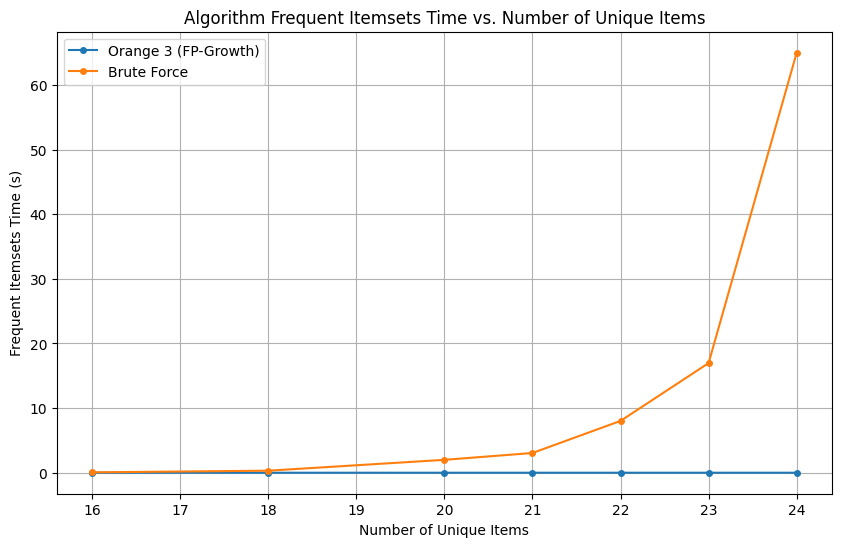

In [18]:
# Create line plot frequent itemsets time comparison
plt.figure(figsize=(10, 6)) # Adjust figure size as needed

# Plot Orange 3 (FP-Growth) time
plt.plot(execution_time_results_df['Number of Unique Items'],
         execution_time_results_df['Orange 3 (FP-Growth) Frequent Itemsets Time (s)'],
         label='Orange 3 (FP-Growth)',
         marker='o', markersize=4)

# Plot Brute-Force time
plt.plot(execution_time_results_df['Number of Unique Items'],
         execution_time_results_df['Brute-Force Frequent Itemsets Time (s)'],
         label='Brute Force',
         marker='o', markersize=4)

# Add Labels, Title, and Legend
plt.xlabel('Number of Unique Items')
plt.ylabel('Frequent Itemsets Time (s)')
plt.title('Algorithm Frequent Itemsets Time vs. Number of Unique Items')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

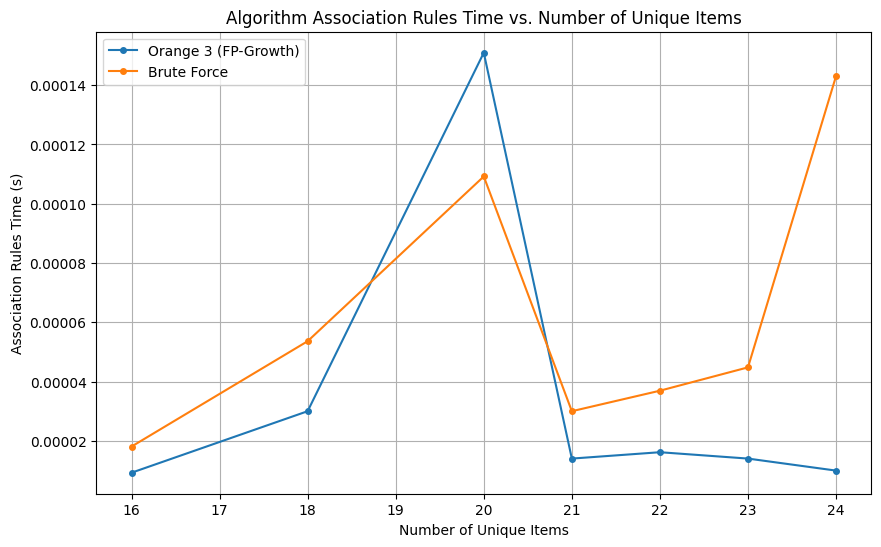

In [19]:
# Create line plot association rules time comparison
plt.figure(figsize=(10, 6)) # Adjust figure size as needed

# Plot Orange 3 (FP-Growth) time
plt.plot(execution_time_results_df['Number of Unique Items'],
         execution_time_results_df['Orange 3 (FP-Growth) Association Rules Time (s)'],
         label='Orange 3 (FP-Growth)',
         marker='o', markersize=4)

# Plot Brute-Force time
plt.plot(execution_time_results_df['Number of Unique Items'],
         execution_time_results_df['Brute-Force Association Rules Time (s)'],
         label='Brute Force',
         marker='o', markersize=4)

# Add Labels, Title, and Legend
plt.xlabel('Number of Unique Items')
plt.ylabel('Association Rules Time (s)')
plt.title('Algorithm Association Rules Time vs. Number of Unique Items')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

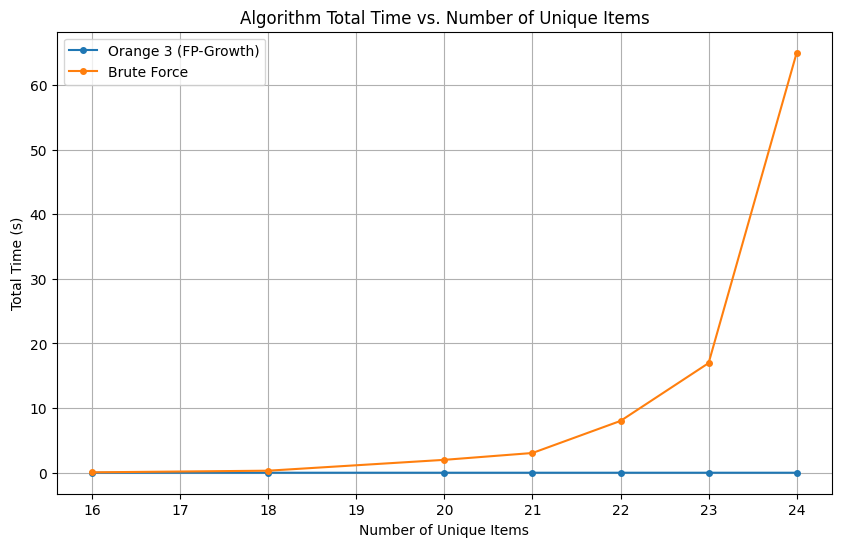

In [20]:
# Create line plot total time comparison
plt.figure(figsize=(10, 6)) # Adjust figure size as needed

# Plot Orange 3 (FP-Growth) time
plt.plot(execution_time_results_df['Number of Unique Items'],
         execution_time_results_df['Orange 3 (FP-Growth) Total Time (s)'],
         label='Orange 3 (FP-Growth)',
         marker='o', markersize=4)

# Plot Brute-Force time
plt.plot(execution_time_results_df['Number of Unique Items'],
         execution_time_results_df['Brute-Force Total Time (s)'],
         label='Brute Force',
         marker='o', markersize=4)

# Add Labels, Title, and Legend
plt.xlabel('Number of Unique Items')
plt.ylabel('Total Time (s)')
plt.title('Algorithm Total Time vs. Number of Unique Items')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()